In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris = load_iris()
data = iris.data
target = iris.target
df = pd.DataFrame(data, columns=iris.feature_names)
df['target'] = target
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
X = df.iloc[:, :4].values
y = df['species'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=82)


In [4]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

nvclassifier = GaussianNB()
nvclassifier.fit(X_train, y_train)

y_pred = nvclassifier.predict(X_test)

In [5]:
print("Predicted labels:", y_pred)


Predicted labels: ['virginica' 'virginica' 'setosa' 'setosa' 'setosa' 'virginica'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor'
 'virginica' 'setosa' 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'versicolor' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor']


In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.93


In [7]:
y_compare = np.vstack((y_test, y_pred)).T
print("Comparison of test and predicted labels (first 5 samples):\n", y_compare[:5, :])


Comparison of test and predicted labels (first 5 samples):
 [['virginica' 'virginica']
 ['virginica' 'virginica']
 ['setosa' 'setosa']
 ['setosa' 'setosa']
 ['setosa' 'setosa']]


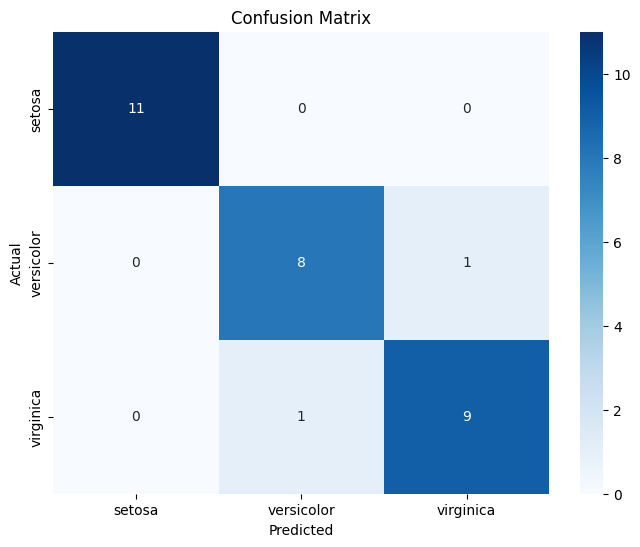

In [8]:
cm = confusion_matrix(y_test, y_pred)


# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=species_map.values(), yticklabels=species_map.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
corrPred = np.trace(cm)
falsePred = cm.sum() - corrPred

In [10]:
print('\nCorrect predictions:', corrPred)
print('False predictions:', falsePred)


Correct predictions: 28
False predictions: 2


In [11]:
accuracy_from_cm = corrPred / cm.sum()
print('\n\nAccuracy of the Naive Bayes Classification is:', accuracy_from_cm)



Accuracy of the Naive Bayes Classification is: 0.9333333333333333
